In [1]:
import numpy as np
from numpy import linalg as LA
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import time
import pandas as pd
import ast

# Create data folder (optional)
!mkdir -p data

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Path to your dataset folder
path = "/content/drive/MyDrive/Colab Notebooks/movies/"

# Load datasets
movies = pd.read_csv(path + "movies_metadata.csv", low_memory=False)
credits = pd.read_csv(path + "credits.csv")
keywords = pd.read_csv(path + "keywords.csv")
ratings = pd.read_csv(path + "ratings_small.csv")
links = pd.read_csv(path + "links.csv")
links_small = pd.read_csv(path + "links_small.csv")

print("All datasets loaded successfully!")

print("Credits: ", credits.columns)
print("Keywords: ", keywords.columns)
print("Links: ", links.columns)
print("Links_small: ", links_small.columns)
print("Movies: ", movies.columns)
print("Ratings: ", ratings.columns)

# We are loading all the Movie Datasets from Google Drive
# This include Title, Credits, Ratings
# After oading, we print columns to make sure everything is loaded correctly



Mounted at /content/drive
All datasets loaded successfully!
Credits:  Index(['cast', 'crew', 'id'], dtype='object')
Keywords:  Index(['id', 'keywords'], dtype='object')
Links:  Index(['movieId', 'imdbId', 'tmdbId'], dtype='object')
Links_small:  Index(['movieId', 'imdbId', 'tmdbId'], dtype='object')
Movies:  Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')
Ratings:  Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')


In [2]:
# Helper function to parse JSON-like fields
def parse_field(x):
    try:
        items = ast.literal_eval(x)
        return " ".join([d['name'] for d in items])
    except:
        return ""

# Clean text fields
movies['genres_clean'] = movies['genres'].apply(parse_field)
keywords['keywords_clean'] = keywords['keywords'].apply(parse_field)
credits['cast_clean'] = credits['cast'].apply(parse_field)
credits['crew_clean'] = credits['crew'].apply(parse_field)

# Ensure IDs match type (string)
movies['id'] = movies['id'].astype(str)
credits['id'] = credits['id'].astype(str)
keywords['id'] = keywords['id'].astype(str)

# Merge credits + keywords into movies using movie ID
movies = movies.merge(credits, on='id', how='left')
movies = movies.merge(keywords, on='id', how='left')

print("Datasets merged successfully!")

# This cell cleans important text fields
# This include Genres, Cast, and Crew
# This also converts ID's into strings
# and merges credits and keywords into a singular master table


Datasets merged successfully!


Mean rating:  5.611607506702412
Minimum votes for top 10% movies:  156.0
Number of qualified movies: 4680


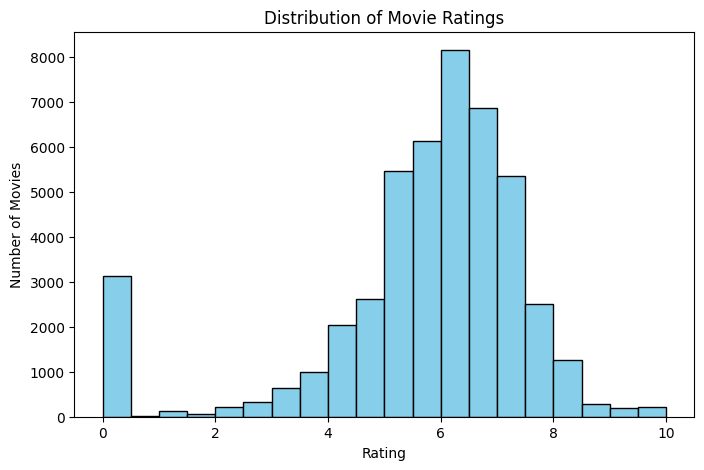

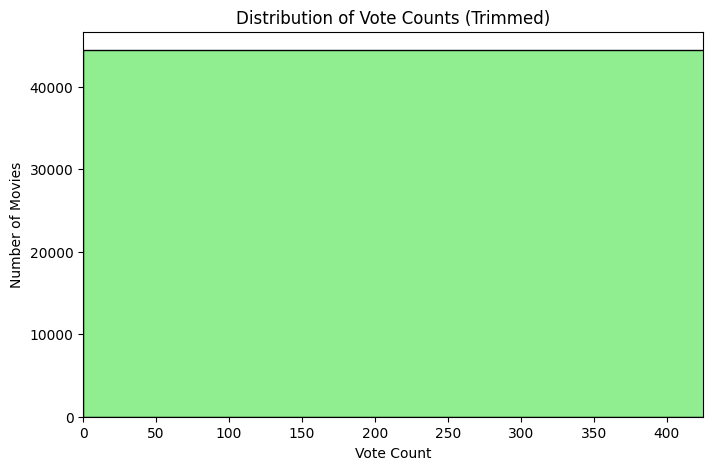

In [3]:
import matplotlib.pyplot as plt

# Mean of the movies
mean_rating = movies['vote_average'].mean()
print('Mean rating: ', mean_rating)

# Minimum of the movies using the 90% percentile of vote counts
min_votes = movies['vote_count'].quantile(0.9)
print('Minimum votes for top 10% movies: ', min_votes)

# Finding the number of movies that qualify (top 10% by vote count)
qualified_movies = movies[movies['vote_count'] >= min_votes]
print('Number of qualified movies:', qualified_movies.shape[0])

# Visualization of vote average
plt.figure(figsize=(8,5))
plt.hist(movies['vote_average'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Ratings")
plt.show()

# Visualization of vote count (trimmed to 95% percentile)
plt.figure(figsize=(8,5))
plt.hist(movies['vote_count'], bins=30, color='lightgreen', edgecolor='black')
plt.xlabel("Vote Count")
plt.ylabel("Number of Movies")
plt.title("Distribution of Vote Counts (Trimmed)")
plt.xlim(0, movies['vote_count'].quantile(0.95))  # trim extreme outliers
plt.show()

# Now we calculate mean rating, filtering for top 10% Vote getters
# Graph visualizes distribution of ratings and vote count
# To try and understand trends and outliers


In [4]:
# Fill NaNs with empty string for genres (already in movies)
movies['genres_clean'] = movies['genres_clean'].fillna('')

# Merge keywords and credits into movies (already done above), now fill NaNs
movies['keywords_clean'] = movies['keywords_clean'].fillna('')
movies['cast_clean'] = movies['cast_clean'].fillna('')
movies['crew_clean'] = movies['crew_clean'].fillna('')

# Create combined text column
movies['combined_text'] = (movies['genres_clean'] + ' ' +
                           movies['keywords_clean'] + ' ' +
                           movies['cast_clean'] + ' ' +
                           movies['crew_clean'])

# Check the result
print(movies[['title', 'combined_text']].head())

# Now, We fill missing values and combine genres and keywords
# This 'Combined_text' column will be the basis
# for our Recommendation algorithm



                         title  \
0                    Toy Story   
1                      Jumanji   
2             Grumpier Old Men   
3            Waiting to Exhale   
4  Father of the Bride Part II   

                                       combined_text  
0  Animation Comedy Family jealousy toy boy frien...  
1  Adventure Fantasy Family board game disappeara...  
2  Romance Comedy fishing best friend duringcredi...  
3  Comedy Drama Romance based on novel interracia...  
4  Comedy baby midlife crisis confidence aging da...  


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer (ignore common English words)
tfidf = TfidfVectorizer(stop_words='english')

# Fit and transform the combined text column
tfidf_matrix = tfidf.fit_transform(movies['combined_text'])

# Check shape
print('TF-IDF matrix shape:', tfidf_matrix.shape)

# We transorm the text column into a numberic matrix using TF-IDF
# Which is used to capture the importance of words for each movie
# This allows for comparison based on textual content

TF-IDF matrix shape: (5002, 47368)


In [ ]:
from sklearn.metrics.pairwise import linear_kernel

# Function to get top N movie recommendations based on content similarity
def get_recommendations(title, movies, tfidf_matrix, top_n=10):
    # Find the index of the movie
    idx = movies[movies['title'] == title].index[0]
    # Compute cosine similarity between this movie and all others
    sim_scores = linear_kernel(tfidf_matrix[idx], tfidf_matrix).flatten()
    # Get indices of top N similar movies
    top_indices = sim_scores.argsort()[-top_n-1:-1][::-1]
    # Return titles of recommended movies
    return movies.iloc[top_indices][['title']]

# Example usage
get_recommendations("The Dark Knight", movies, tfidf_matrix)  # get top 10 similar movies

# This cell replaces the memory-heavy full cosine similarity matrix
# Now we compute similarities only for the movie we query
# Keeps memory usage low and allows recommendations to run in Colab


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
# Create a Series to map movie titles to indices
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

# Check a few entries
print(indices.head())

# This cell creates a mapping from movie titles to their row indicies
# This allows us to quickly look up a movies index
# while generating movie reccomendations

title
Toy Story                      0
Jumanji                        1
Grumpier Old Men               2
Waiting to Exhale              3
Father of the Bride Part II    4
dtype: int64


In [ ]:
# Ensure movieId is string to match movies['id']
ratings['movieId'] = ratings['movieId'].astype(str)

# Example: choose a user ID
user_id = 3

# Get all movies rated by this user, sorted by rating descending
user_movies = ratings[ratings['userId'] == user_id].sort_values(by='rating', ascending=False)

# Merge with movies DataFrame to get titles
user_movies_titles = user_movies.merge(
    movies[['title','id']],
    left_on='movieId',
    right_on='id'
)[['title','rating']]

# Show the user's top 5 rated movies
print(f"User {user_id}'s top rated movies:")
print(user_movies_titles.head())

# Use the user's highest-rated movie to generate recommendations
top_movie_title = user_movies_titles.iloc[0]['title']

# Generate recommendations using memory-safe function
recommended_movies = get_recommendations(top_movie_title, movies, tfidf_matrix)

print(f"\nGenerating recommendations for User {user_id} based on '{top_movie_title}':")
print(recommended_movies['title'].to_list())

# ---------------------------------------------------------
# This cell personalizes recommendations for a specific user
# Finds user's top-rated movies, picks highest rated as seed
# Uses memory-safe get_recommendations() function
# Converts IDs to same type to avoid merge errors


User 3's top rated movies:
                      title  rating
0  The Million Dollar Hotel     5.0
1         Three Colors: Red     4.0
2           Say Anything...     4.0
3        Young and Innocent     3.5
4                      Rope     3.5

Generating recommendations for User 3 based on 'The Million Dollar Hotel':
['Faraway, So Close!', 'Wings of Desire', 'The End of Violence', 'Until the End of the World', 'Buena Vista Social Club', 'U2: Rattle and Hum', 'Two Girls and a Guy', 'City of Angels', "Say It Isn't So", 'Unmade Beds']


Enter user ID to get recommendations: 3

User 3's top rated movies:
                      title  rating
0  The Million Dollar Hotel     5.0
1         Three Colors: Red     4.0
2           Say Anything...     4.0
3        Young and Innocent     3.5
4                      Rope     3.5

Recommendations based on 'The Million Dollar Hotel':
['Faraway, So Close!', 'Wings of Desire', 'The End of Violence', 'Until the End of the World', 'Buena Vista Social Club', 'U2: Rattle and Hum', 'Two Girls and a Guy', 'City of Angels', "Say It Isn't So", 'Unmade Beds']

Predicted ratings for recommended movies:
Faraway, So Close!: 1.07
Wings of Desire: 1.07
The End of Violence: 1.06
Until the End of the World: 0.87
Buena Vista Social Club: 0.78
U2: Rattle and Hum: 0.49
Two Girls and a Guy: 0.48
City of Angels: 0.42
Say It Isn't So: 0.39
Unmade Beds: 0.37


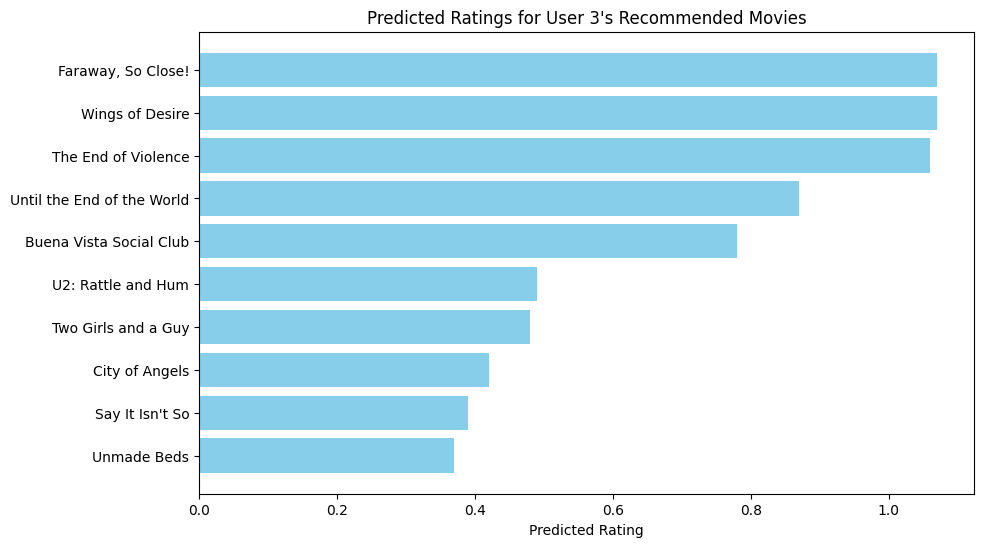

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import linear_kernel

# Ask for user ID
user_id = input("Enter user ID to get recommendations: ")
user_id = int(user_id)  # convert to int

# Ensure movieId is string to match movies['id']
ratings['movieId'] = ratings['movieId'].astype(str)

# Get all movies rated by this user
user_movies = ratings[ratings['userId'] == user_id].sort_values(by='rating', ascending=False)

if user_movies.empty:
    print(f"No ratings found for User {user_id}")
else:
    # Merge with movies DataFrame to get titles
    user_movies_titles = user_movies.merge(
        movies[['title','id']],
        left_on='movieId',
        right_on='id'
    )[["title","rating"]]

    print(f"\nUser {user_id}'s top rated movies:")
    print(user_movies_titles.head())

    # Use top-rated movie as seed
    top_movie_title = user_movies_titles.iloc[0]["title"]
    user_top_rating = user_movies_titles.iloc[0]["rating"]

    # Generate recommendations
    recommended_movies = get_recommendations(top_movie_title, movies, tfidf_matrix)
    print(f"\nRecommendations based on '{top_movie_title}':")
    print(recommended_movies["title"].to_list())

    # Predict ratings based on similarity to top movie
    predicted = []
    idx_top = movies[movies['title'] == top_movie_title].index[0]
    for rec_title in recommended_movies['title']:
        idx_rec = movies[movies['title'] == rec_title].index[0]
        sim = linear_kernel(tfidf_matrix[idx_top], tfidf_matrix[idx_rec])[0][0]
        predicted_rating = min(user_top_rating * sim, 5)
        predicted.append((rec_title, round(predicted_rating, 2)))

    print("\nPredicted ratings for recommended movies:")
    for title, rating in predicted:
        print(f"{title}: {rating}")

    # Plot predicted ratings
    titles, ratings_pred = zip(*predicted)
    plt.figure(figsize=(10,6))
    plt.barh(titles, ratings_pred, color='skyblue')
    plt.xlabel("Predicted Rating")
    plt.title(f"Predicted Ratings for User {user_id}'s Recommended Movies")
    plt.gca().invert_yaxis()  # highest rated on top
    plt.show()

# ---------------------------------------------------------
# This cell: interactive user input
# Shows user's top movies, recommended movies, predicted ratings
# And visualizes predicted ratings in a horizontal bar chart
